<a href="https://colab.research.google.com/github/charujhagrawat20/StackIt/blob/main/Prac16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def to_bipolar(pattern):
    return np.where(pattern == 0, -1, 1)

In [ ]:
class HopfieldNetwork:
    def __init__(self, num_neurons):
        self.num_neurons = num_neurons
        self.weights = np.zeros((num_neurons, num_neurons))

    def train(self, patterns):
        for p in patterns:
            self.weights += np.outer(p, p)
        np.fill_diagonal(self.weights, 0)
        self.weights /= len(patterns)

    def recall(self, pattern, steps=10):
        s = pattern.copy()
        for _ in range(steps):
            for i in range(self.num_neurons):
                net_input = np.dot(self.weights[i], s)
                s[i] = 1 if net_input >= 0 else -1
        return s

In [ ]:
patterns = [
    np.array([
        1,0,0,0,1,
        0,1,0,1,0,
        0,0,1,0,0,
        0,1,0,1,0,
        1,0,0,0,1
    ]),
    np.array([
        0,1,1,1,0,
        1,0,0,0,1,
        1,0,0,0,1,
        1,0,0,0,1,
        0,1,1,1,0
    ])
]

In [ ]:
patterns = [to_bipolar(p) for p in patterns]

In [ ]:
hopfield = HopfieldNetwork(num_neurons=25)
hopfield.train(patterns)

In [ ]:
noisy_pattern = patterns[0].copy()
noise_indices = np.random.choice(25, 6, replace=False)
noisy_pattern[noise_indices] *= -1


In [ ]:
recalled_pattern = hopfield.recall(noisy_pattern)

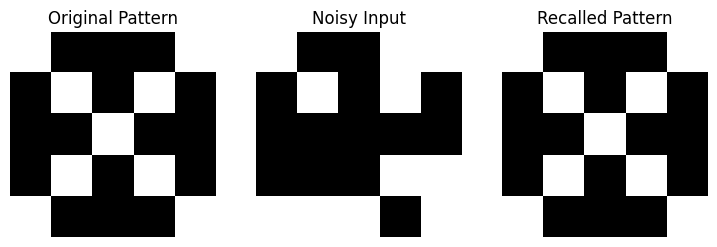

In [ ]:
def plot_pattern(pattern, title, pos):
    plt.subplot(1, 3, pos)
    plt.imshow(pattern.reshape(5,5), cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(9,3))
plot_pattern(patterns[0], "Original Pattern", 1)
plot_pattern(noisy_pattern, "Noisy Input", 2)
plot_pattern(recalled_pattern, "Recalled Pattern", 3)
plt.show()